Por: Juan Aros y Alma Wettig

# MODELO 01: Random Forest + Support Vector Machine (SVM)
Este script realiza la clasificación supervisada de una imagen Sentinel-2 utilizando dos algoritmos de aprendizaje automático: Random Forest (Bosques Aleatorios) y Support Vector Machines (Máquinas de Vectores de Soporte). A partir de un shapefile de entrenamiento con etiquetas de cobertura del suelo ('landcover'), se extraen muestras espectrales de la imagen para entrenar ambos modelos. Posteriormente, se clasifica la imagen completa utilizando los modelos entrenados y se visualizan los resultados en forma de mapas temáticos. El script también evalúa el rendimiento de cada modelo utilizando métricas estándar de clasificación y guarda los modelos entrenados para usos posteriores.

# 1. Preparación
Antes de ejecutar este script, asegúrese de tener instaladas las siguientes bibliotecas de Python:
- numpy
- geopandas
- rasterio
- shapely
- scikit-learn
- matplotlib
- joblib

In [2]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 22.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rasterio]4/5 [rasterio]


# Importación de librerías necesarias
 - numpy: para manipulación eficiente de matrices y vectores numéricos.
 - geopandas: para trabajar con datos vectoriales geoespaciales (shapefiles).
 - rasterio: para lectura y escritura de datos raster (imágenes geográficas).
 - rasterio.mask: para recortar imágenes raster usando geometrías vectoriales.
 - shapely.mapping: para convertir geometrías a formato compatible con rasterio.
 - scikit-learn: para crear, entrenar y evaluar modelos de clasificación supervisada.
 - RandomForestClassifier: modelo de ensamble basado en árboles de decisión.
 - SVC: modelo de clasificación por máquinas de vectores de soporte (SVM).
 - train_test_split: división de los datos en conjuntos de entrenamiento y prueba.
 - classification_report: métricas de evaluación (precisión, recall, F1).
 - joblib: para guardar los modelos entrenados en disco.
 - matplotlib.pyplot: para visualizar los mapas de clasificación generados.

In [14]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib
import matplotlib.pyplot as plt

# 2. Definición de rutas y carga de datos vectoriales

 Se definen las rutas de los archivos necesarios para el proceso de clasificación:
 - input_img: imagen raster de entrada (Sentinel-2) con resolución espacial de 20 metros.
 - in_msk_img: máscara de píxeles válidos de la imagen (en este caso, todos los valores son válidos).
 - vec_train_file: shapefile con las muestras de entrenamiento etiquetadas, que contiene información sobre las clases de cobertura del suelo.
   
 A continuación, se carga el shapefile usando GeoPandas, lo cual permite acceder a las geometrías y atributos asociados a las muestras de entrenamiento.

In [15]:
# Rutas
input_img = "./DATOS_OUR/sentinel2_2018_input_img.tif"
in_msk_img = "./DATOS_OUR/sentinel2_2018_in_msk_img.tif"
vec_train_file = "./DATOS_OUR/Training/Training.shp"

# Cargar shapefile
gdf = gpd.read_file(vec_train_file)

# 3. Lectura de imagen raster y máscara de píxeles válidos

 Se abre la imagen Sentinel-2 utilizando Rasterio y se cargan todas las bandas en una matriz tridimensional con forma (bandas, filas, columnas).
 Luego, esta matriz se reorganiza en una estructura bidimensional (n_pixels, n_bands), donde cada fila representa un píxel y cada columna una banda espectral.
 También se carga la imagen de máscara, que indica qué píxeles son válidos para el análisis. En este caso, todos los píxeles son válidos, pero se mantiene
 este paso para garantizar la compatibilidad con flujos de trabajo donde existan regiones sin datos.

In [16]:
# Leer imagen y máscara
with rasterio.open(input_img) as src:
    img = src.read()  # (bands, rows, cols)
    profile = src.profile

bands, rows, cols = img.shape
X_all = img.reshape(bands, -1).T  # (n_pixels, n_bands)

with rasterio.open(in_msk_img) as msk_src:
    valid_mask = msk_src.read(1).flatten()

# 4. Extracción de muestras de entrenamiento a partir del shapefile

 En este paso se recorre cada geometría del shapefile de entrenamiento.
 Por cada polígono, se realiza un recorte ("mask") sobre la imagen raster para extraer los valores espectrales (bandas) contenidos en dicha área.
 Cada píxel extraído se asocia a la etiqueta de cobertura del suelo correspondiente (almacenada en la columna 'landcover').
 Los valores espectrales de todos los píxeles se agregan a la lista X_train_list, mientras que las etiquetas se guardan en y_train_list.
 Finalmente, ambas listas se convierten en arreglos NumPy que servirán como datos de entrada (X_train) y salida (y_train) para entrenar los modelos de clasificación.

In [17]:
# Extraer muestras de entrenamiento
X_train_list, y_train_list = [], []
for _, row in gdf.iterrows():
    geom = [mapping(row.geometry)]
    label = row["landcover"]

    with rasterio.open(input_img) as src:
        out_image, out_transform = mask(src, geom, crop=True)
        for pixel in zip(*[band.flatten() for band in out_image]):
            X_train_list.append(pixel)
            y_train_list.append(label)

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

# 5. División del conjunto de datos para evaluación del modelo

 Se realiza una división del conjunto de muestras de entrenamiento en dos subconjuntos:
 - 80% para entrenamiento del modelo (X_train_, y_train_)
 - 20% para prueba y evaluación (X_test, y_test)
 Esta separación permite evaluar el rendimiento de los modelos con datos que no fueron vistos durante el entrenamiento,
 lo que ayuda a estimar su capacidad de generalización. Se fija una semilla aleatoria (random_state=42) para asegurar que
 la división sea reproducible en futuras ejecuciones.

In [18]:
# División de prueba solo para evaluación del modelo
X_train_, X_test, y_train_, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 6. Entrenamiento, clasificación y visualización de modelos

 Se definen dos modelos de clasificación supervisada: 
 - Random Forest con 100 árboles y semilla fija para reproducibilidad.
 - SVM (Máquinas de Vectores de Soporte) con kernel RBF y parámetros estándar.

## Para cada modelo:
 1. Se entrena con el subconjunto de datos de entrenamiento.
 2. Se evalúa su desempeño en el conjunto de prueba usando métricas como precisión, recall y F1.
 3. Se clasifica toda la imagen Sentinel-2 en función del modelo entrenado, aplicando la máscara de píxeles válidos.
 4. Se genera un mapa visual de la clasificación, usando una paleta de colores para diferenciar las clases.
 5. Finalmente, el modelo entrenado se guarda en disco con un nombre identificativo para su uso posterior.


 Entrenando Random Forest...
 Clasificación Random Forest:
               precision    recall  f1-score   support

           1       0.98      0.91      0.94       882
           2       0.97      0.93      0.95      1007
           5       0.99      0.70      0.82       161
           6       0.81      0.96      0.88      1128
           8       0.98      0.73      0.83       234

    accuracy                           0.91      3412
   macro avg       0.95      0.84      0.88      3412
weighted avg       0.92      0.91      0.91      3412

 Clasificando toda la imagen con Random Forest...


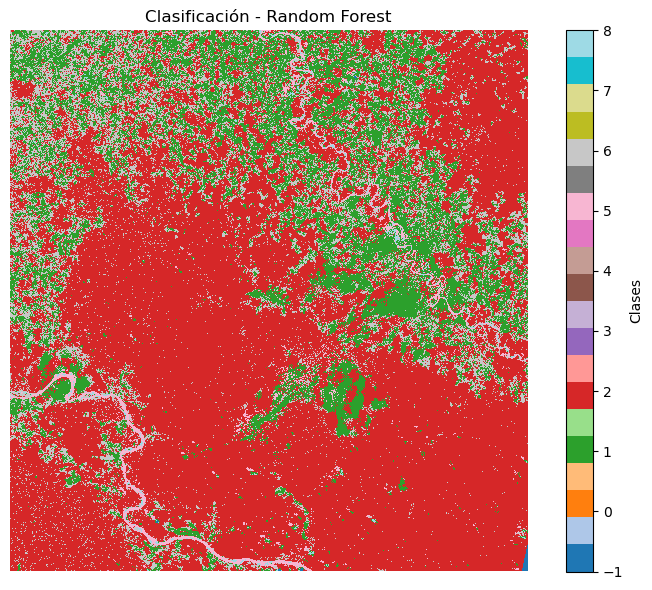


 Entrenando SVM...
 Clasificación SVM:
               precision    recall  f1-score   support

           1       0.94      0.90      0.92       882
           2       0.97      0.93      0.95      1007
           5       0.99      0.61      0.75       161
           6       0.80      0.94      0.87      1128
           8       0.94      0.72      0.82       234

    accuracy                           0.90      3412
   macro avg       0.93      0.82      0.86      3412
weighted avg       0.91      0.90      0.90      3412

 Clasificando toda la imagen con SVM...


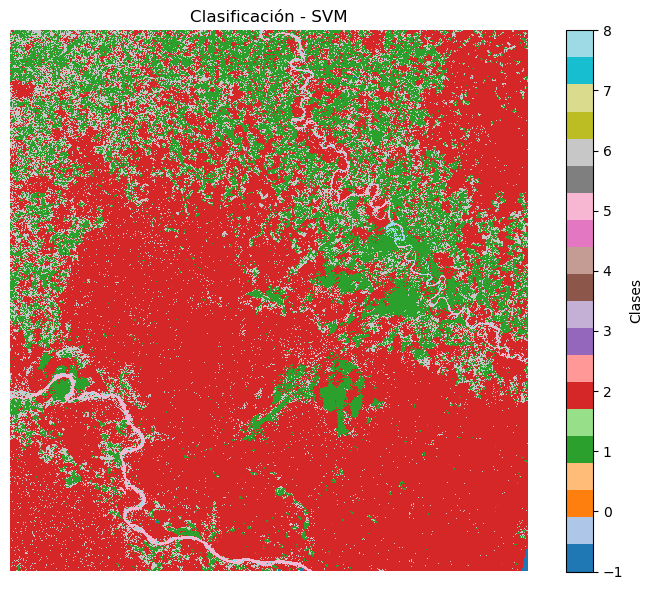

In [19]:
# Modelos
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", C=1, gamma="scale")
}

for name, model in models.items():
    print(f"\n Entrenando {name}...")
    model.fit(X_train_, y_train_)
    preds = model.predict(X_test)
    print(f" Clasificación {name}:\n", classification_report(y_test, preds))

    # Clasificación de la imagen completa
    print(f" Clasificando toda la imagen con {name}...")
    prediction = np.full((rows * cols,), fill_value=-1, dtype=np.int32)
    prediction[valid_mask == 1] = model.predict(X_all[valid_mask == 1])
    classification_map = prediction.reshape(rows, cols)

    # Visualización
    plt.figure(figsize=(8, 6))
    plt.title(f"Clasificación - {name}")
    plt.imshow(classification_map, cmap="tab20", interpolation='none')
    plt.colorbar(label="Clases")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Guardar modelo
    joblib.dump(model, f"modelo_{name.replace(' ', '_').lower()}.pkl")

# 7. Resultados
Los resultados del análisis comparativo entre los modelos Random Forest y SVM muestran que ambos presentan un desempeño sólido en la clasificación de las clases de cobertura del suelo. Random Forest obtuvo una precisión global ligeramente superior (91%) frente a la SVM (90%), reflejando un mejor balance entre precisión y recall en la mayoría de las clases. En particular, Random Forest logró una mejor recuperación (recall) para la clase 5 y un puntaje F1 más alto (0.82 vs 0.75), lo que indica mayor capacidad para identificar correctamente esta clase minoritaria. Sin embargo, SVM mostró un desempeño competitivo con precisiones muy cercanas en las clases 1 y 2, manteniendo un buen equilibrio entre las métricas. En resumen, aunque ambos modelos funcionan bien, Random Forest parece ofrecer una mayor robustez general, especialmente en la detección de clases menos representadas, lo que lo hace preferible para este caso específico de clasificación con datos Sentinel-2.